In [1]:
import numpy as np
import math
import json
import time
from IPython.display import HTML

from ipynb.fs.full.forcemodel import IForceModel, GravityForce
from ipynb.fs.full.integrator import IIntegrator, SymplecticEuler, VelocityVerlet
from ipynb.fs.full.env import SolarSystemEnv, run_simulation, run_script_simulation, adjust_barycentric
from ipynb.fs.full.vis import visualize_trajectories, plot_static_trajectories
from ipynb.fs.full.helpers import save_states, load_states
from ipynb.fs.full.ship import SimpleImpulseShip, Maneuver, simple_action_space
from ipynb.fs.full.rlmontecarlo import train_mc, MonteCarloAgent

Cool but unstable with really massive suns
bodies = [
    # Masses (kg)
    np.array([
        1.0e31,
        1.0e31,
        1.0e31,
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.97e11, -0.243e11],   
        [-0.97e11, 0.243e11],
        [0.0, 0.0], 
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.466e5, 0.432e5],    
        [0.466e5, 0.432e5],
        [-0.932e5, -0.864e5], 
    ]),
    # Names
    np.array([
        "One",
        "Two",
        "Three",
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "red",        
        "blue",
        "green",
    ]),
]

In [ ]:
# This precompiles simulation for njit
bodies = [
    # Masses (kg)
    np.array([
        1.5e10,
        1.5e10
    ]),
    # Positions (x, y) in meters (approx semi-major axes on x-axis)
    np.array([
        [0.97, -0.243],
        [-0.97, 0.243]
    ]),
    # Velocities (vx, vy) in m/s (circular orbit approximation)
    np.array([
        [0.466, 0.432],
        [0.466, 0.432]
    ]),
    # Names
    np.array([
        "One",
        "Two"
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "red",
        "blue"
    ]),
]
dt=0.0001
n_steps=1000
states = run_simulation(GravityForce, VelocityVerlet, bodies, dt=dt, n_steps=n_steps, records_len=500)

# First try with a ship that has thrust #
Simulation of a Ship on a geostationary orbit with a single impulse thrust 

In [6]:
bodies = [
    # Masses
    np.array([
        1.9885e30,      # Sun
        5.972e24,       # Earth
        7.342e22,       # Luna
        1.0e5,          # Ship
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.0, 0.0],                     # Sun
        [1.496e11, 0.0],                # Earth
        [1.496e11 + 3.844e8, 0.0],      # Luna
        [1.496e11 + 3.6e7, 0.0],        # Ship
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.0, 0.0],                       # Sun
        [0.0, 29783.0],                   # Earth
        [0.0, 29783.0 + 1022.0],          # Luna
        [0.0, 29783.0 + 3055.0],         # Ship
    ]),
    # Names of celestial bodies
    np.array([
        "Sun",
        "Earth",
        "Moon",
        "Ship"
    ]),
    # Colors for visuals
    np.array([
        "orange",     # Sun
        "blue",       # Earth
        "gray",       # Moon (Luna)
        "lightblue",  # Ship
    ]),
]

ship = SimpleImpulseShip(len(bodies[0])-1, bodies[0][-1], 1.076e7, simple_action_space, None)

In [7]:
dt=10.0
n_steps=200000
#scale=1.0/1.496e11
#centre_body=None
scale=1.0/4e8
centre_body="Earth"
xlim=(-1, 1)
ylim=(-1, 1)

In [8]:
maneuvers = [
    Maneuver(60 * 9000, 1, 3),
    #Maneuver(60 * 20000, 2400, 3),
]

In [9]:
states = run_script_simulation(GravityForce, VelocityVerlet, bodies, ship=ship, maneuvers=maneuvers, dt=dt, n_steps=n_steps, records_len=1000)

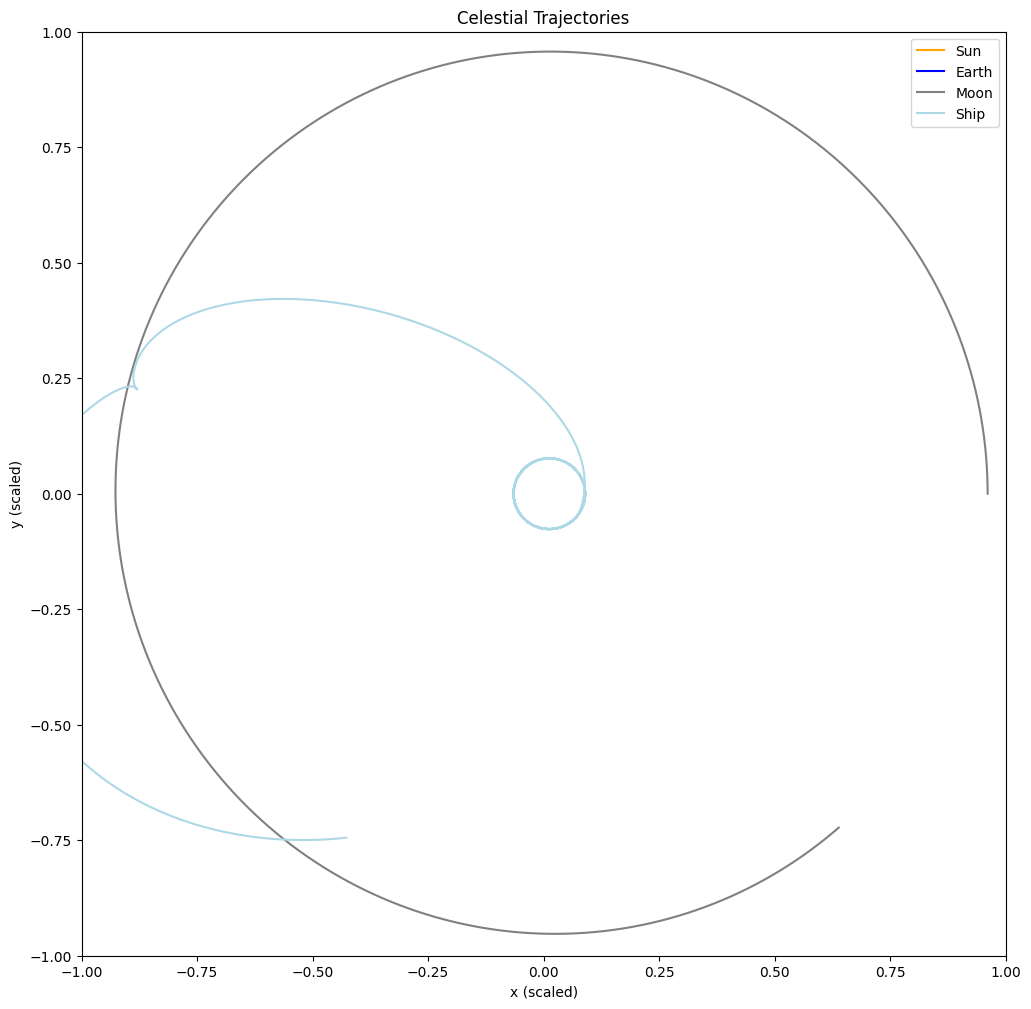

In [10]:
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim)

In [11]:
#anim = visualize_trajectories(states=states, body_names=bodies[3], colors=bodies[4], interval=20, scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, save_path="geostationaryfling.gif")
#HTML(anim.to_jshtml())

# Geostationary orbit with the Sun's tidal force #

In [12]:
bodies = [
    # Masses
    np.array([
        1.9885e30,      # Sun
        5.972e24,       # Earth
        7.342e22,       # Luna
        1.0e5,          # Ship
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.0, 0.0],                     # Sun
        [1.496e11, 0.0],                # Earth
        [1.496e11 + 3.844e8, 0.0],      # Luna
        [1.496e11 + 3.6e7, 0.0],        # Ship
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.0, 0.0],                       # Sun
        [0.0, 29783.0],                   # Earth
        [0.0, 29783.0 + 1022.0],          # Luna
        [0.0, 29783.0 + 3055.0],         # Ship
    ]),
    # Names of celestial bodies
    np.array([
        "Sun",
        "Earth",
        "Moon",
        "Ship"
    ]),
    # Colors for visuals
    np.array([
        "orange",     # Sun
        "blue",       # Earth
        "gray",       # Moon (Luna)
        "lightblue",  # Ship
    ]),
]

In [13]:
dt=60.0
n_steps=100000
scale=1.0/4e8
centre_body="Earth"
xlim=(-1, 1)
ylim=(-1, 1)

In [14]:
states = run_simulation(GravityForce, VelocityVerlet, bodies, ship=ship, dt=dt, n_steps=n_steps, records_len=1000)

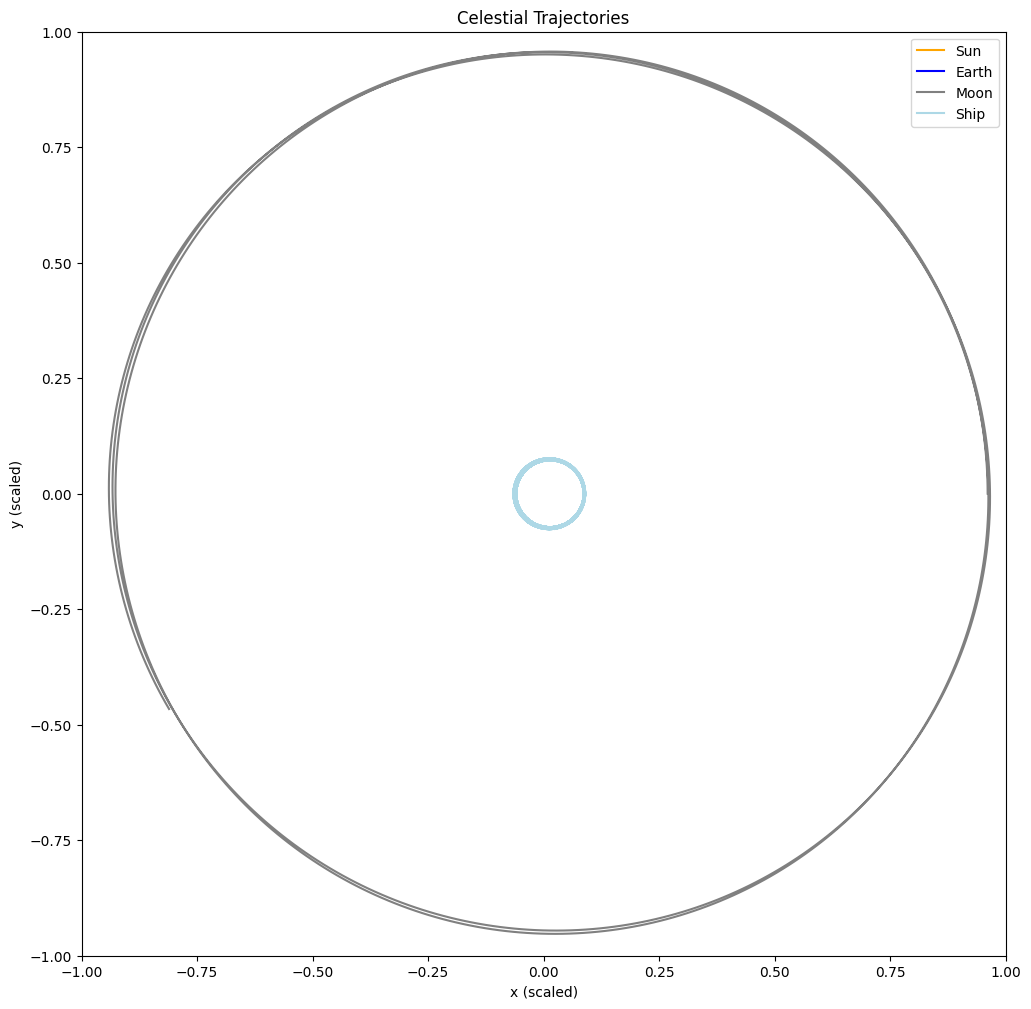

In [15]:
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim)

In [16]:
#anim = visualize_trajectories(states=states, body_names=bodies[3], colors=bodies[4], interval=20, scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, save_path="geostationaryship.gif")
#HTML(anim.to_jshtml())

# Geostationary orbit without the Sun's tidal force #

In [17]:
bodies = [
    # Masses
    np.array([
        5.972e24,       # Earth
        7.342e22,       # Luna
        1.0e5,          # Ship
    ]),
    # Positions (x, y) in meters
    np.array([
        [0.0, 0.0],                # Earth
        [3.844e8, 0.0],      # Luna
        [3.6e7, 0.0],        # Ship
    ]),
    # Velocities (vx, vy) in m/s
    np.array([
        [0.0, 0.0],                   # Earth
        [0.0, 1022.0],          # Luna
        [0.0, 3055.0],         # Ship
    ]),
    # Names of celestial bodies
    np.array([
        "Earth",
        "Moon",
        "Ship"
    ]),
    # Colors for visuals
    np.array([
        "blue",       # Earth
        "gray",       # Moon (Luna)
        "lightblue",  # Ship
    ]),
]

ship = SimpleImpulseShip(len(bodies[0])-1, bodies[0][-1], 1.076e7, simple_action_space, None)

In [18]:
dt=60.0
n_steps=100000
scale=1.0/4e8
centre_body="Earth"
xlim=(-1, 1)
ylim=(-1, 1)

In [19]:
states = run_simulation(GravityForce, VelocityVerlet, bodies, ship=ship, dt=dt, n_steps=n_steps, records_len=1000)

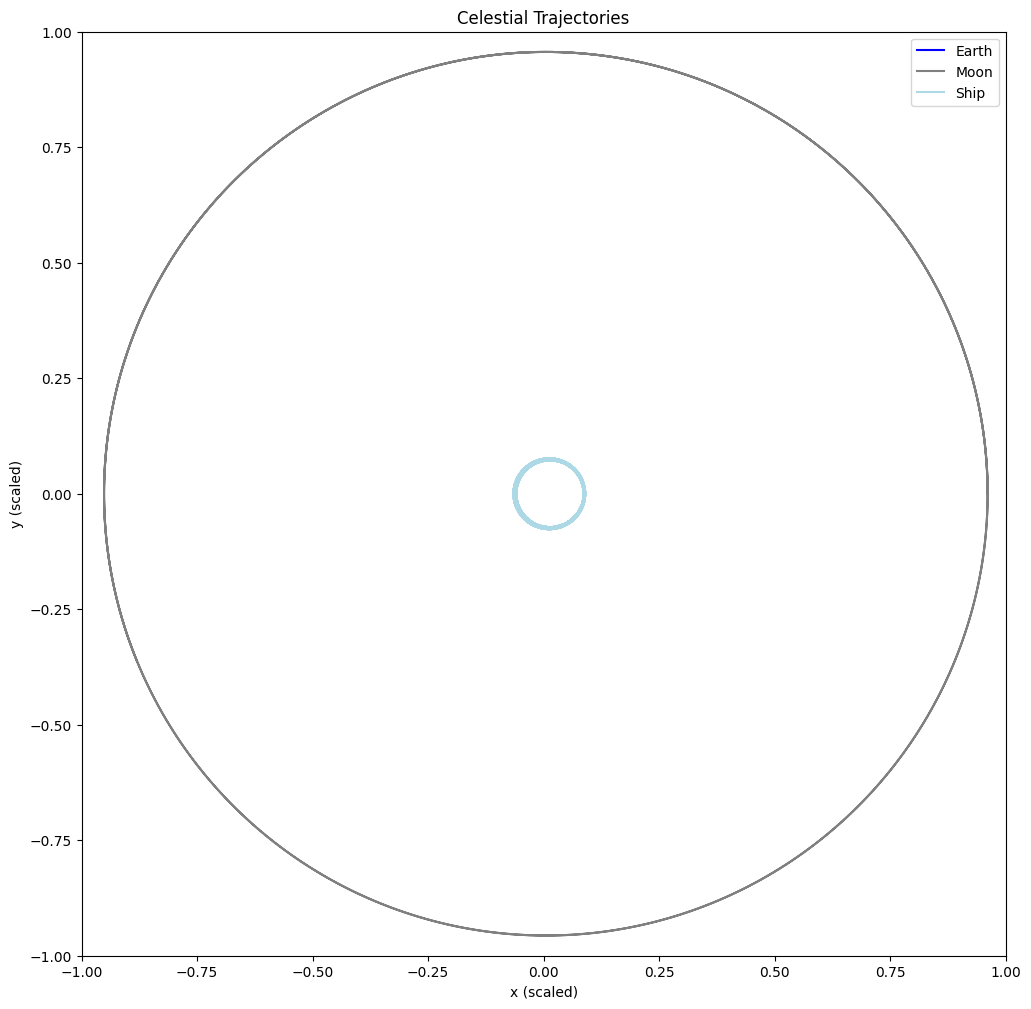

In [20]:
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim)

In [21]:
#anim = visualize_trajectories(states=states, body_names=bodies[3], colors=bodies[4], interval=20, scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, save_path=None)
#HTML(anim.to_jshtml())

# Three Body Problem ##

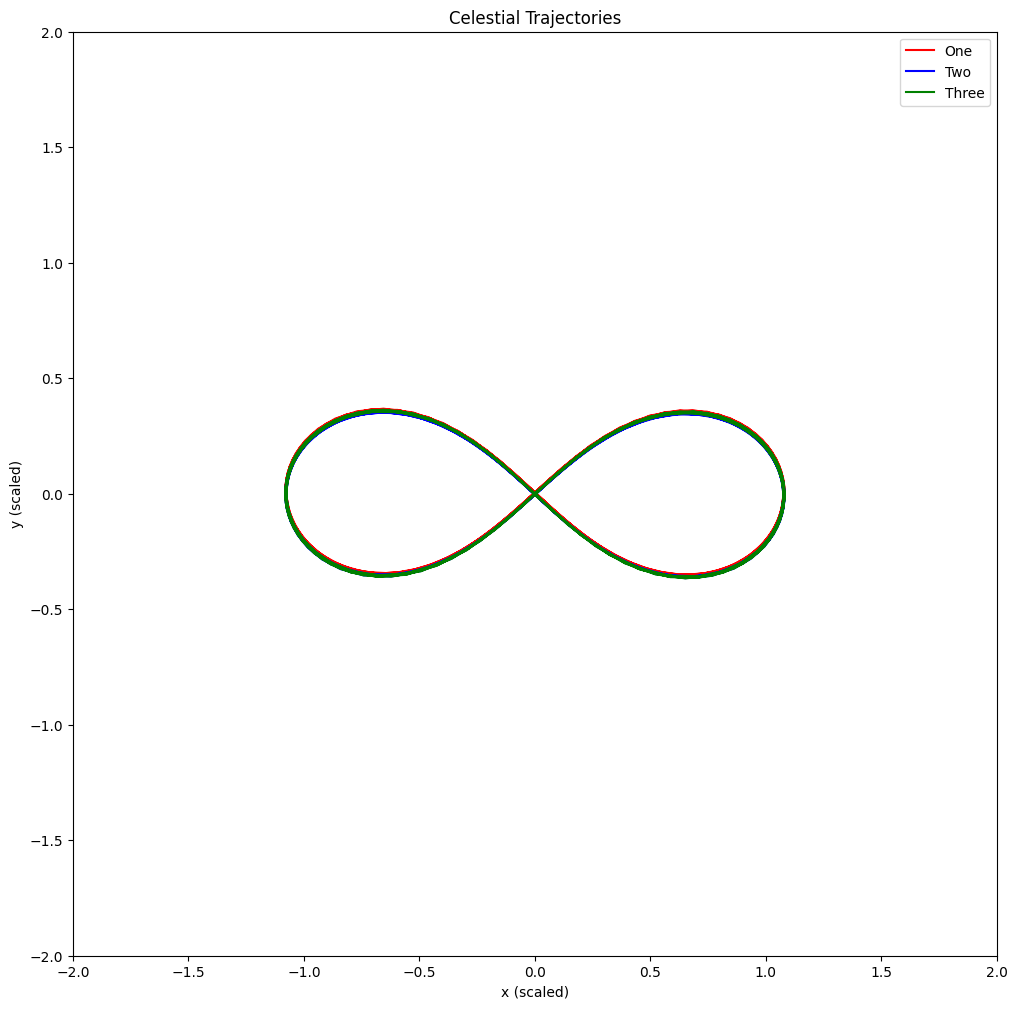

In [25]:
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=1.0, xlim=(-2.0, 2.0), ylim=(-2.0, 2.0))